In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
df = pd.read_excel("/content/AAPL.xlsx")

In [47]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


In [48]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
179,2018-03-05,175.210007,180.000000,174.270004,179.979996,179.979996,139852700
180,2018-03-12,180.289993,183.500000,177.619995,178.020004,178.020004,155417500
181,2018-03-19,177.320007,177.470001,164.940002,164.940002,164.940002,172670700
182,2018-03-26,168.070007,175.149994,165.190002,167.779999,167.779999,157898400
183,2018-03-29,167.804993,171.750000,166.899994,167.779999,167.779999,38398505


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       184 non-null    datetime64[ns]
 1   Open       184 non-null    float64       
 2   High       184 non-null    float64       
 3   Low        184 non-null    float64       
 4   Close      184 non-null    float64       
 5   Adj Close  184 non-null    float64       
 6   Volume     184 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 10.2 KB


In [50]:
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [51]:
df = df.drop_duplicates()

In [52]:
df["Date"] = pd.to_datetime(df["Date"])

In [53]:
df = df.sort_values("Date")

In [54]:
print(df[["Date"]].head(10))

        Date
0 2014-09-29
1 2014-10-06
2 2014-10-13
3 2014-10-20
4 2014-10-27
5 2014-11-03
6 2014-11-10
7 2014-11-17
8 2014-11-24
9 2014-12-01


In [55]:
df["Daily Price Change"] = df["Close"].diff()

In [56]:
print(df[["Daily Price Change"]].head(10))

   Daily Price Change
0                 NaN
1            1.110000
2           -3.060005
3            7.550003
4            2.779999
5            1.010002
6            5.169998
7            2.290001
8            2.459999
9           -3.930000


In [57]:
df["Daily Return"] = ((df["Close"] - df["Open"]) / df["Open"]) * 100
print(df[["Daily Return"]].head(10))

   Daily Return
0     -0.964304
1      0.780396
2     -3.611965
3      7.017902
4      3.004294
5      0.729995
6      4.733079
7      1.925268
8      1.780062
9     -3.206799


In [58]:
print("\nStock Price Analysis:")
print("Highest Price:", df["High"].max())
print("Lowest Price:", df["Low"].min())
print("Average Closing Price:", df["Close"].mean())


Stock Price Analysis:
Highest Price: 183.5
Lowest Price: 89.470001
Average Closing Price: 127.35266294565217


In [66]:
print("\nDaily Price Change:")
df["Daily Percentage Change"] = df["Close"].pct_change() * 100
print(df[["Date", "Close", "Daily Price Change", "Daily Percentage Change"]])


Daily Price Change:
          Date       Close  Daily Price Change  Daily Percentage Change
0   2014-09-29   99.620003                 NaN                      NaN
1   2014-10-06  100.730003            1.110000                 1.114234
2   2014-10-13   97.669998           -3.060005                -3.037829
3   2014-10-20  105.220001            7.550003                 7.730115
4   2014-10-27  108.000000            2.779999                 2.642082
..         ...         ...                 ...                      ...
179 2018-03-05  179.979996            3.769989                 2.139486
180 2018-03-12  178.020004           -1.959992                -1.089005
181 2018-03-19  164.940002          -13.080002                -7.347490
182 2018-03-26  167.779999            2.839997                 1.721836
183 2018-03-29  167.779999            0.000000                 0.000000

[184 rows x 4 columns]


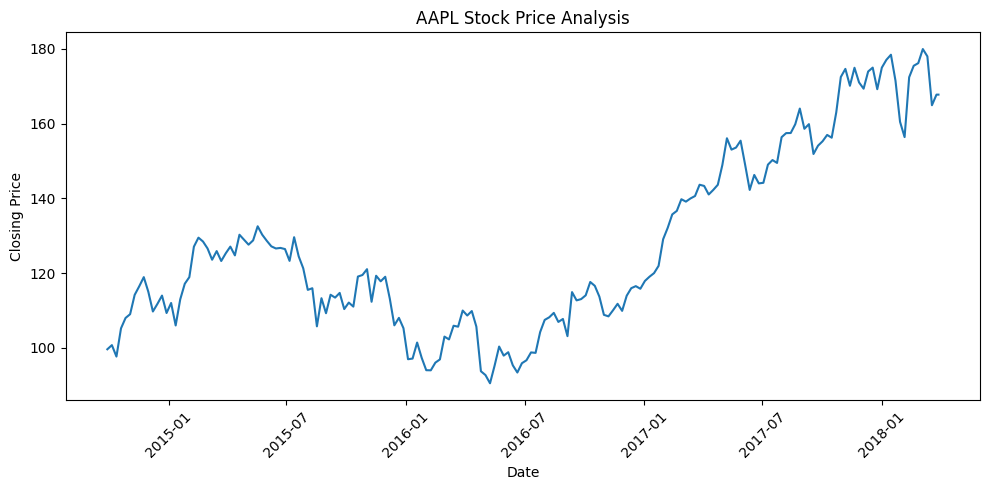

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("AAPL Stock Price Analysis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
df["Daily Percentage Change"] = df["Close"].pct_change() * 100
print(df[["Daily Percentage Change"]].head(10))

   Daily Percentage Change
0                      NaN
1                 1.114234
2                -3.037829
3                 7.730115
4                 2.642082
5                 0.935187
6                 4.742682
7                 2.005606
8                 2.112131
9                -3.304465


In [65]:
# Sort by 'Daily Percentage Change' to find the biggest losses
biggest_losses = df.sort_values(by='Daily Percentage Change', ascending=True)

print("\nDays with the Biggest Losses:")
print(biggest_losses[['Date', 'Close', 'Daily Percentage Change']].head())


Days with the Biggest Losses:
          Date       Close  Daily Percentage Change
82  2016-04-25   93.739998               -11.298261
46  2015-08-17  105.760002                -8.796134
66  2016-01-04   96.959999                -7.885239
181 2018-03-19  164.940002                -7.347490
58  2015-11-09  112.339996                -7.203042


In [67]:
print("\nTrading Volume Analysis:")
print("Average Trading Volume:", df["Volume"].mean())


Trading Volume Analysis:
Average Trading Volume: 191016776.11413044


In [68]:
# Days with Highest Trading Volume
highest_volume_days = df.sort_values(by='Volume', ascending=False)
print("\nDays with Highest Trading Volume:")
print(highest_volume_days[['Date', 'Volume', 'Close']].head())


Days with Highest Trading Volume:
          Date     Volume       Close
47  2015-08-24  500363000  113.290001
17  2015-01-26  465842700  117.160004
30  2015-04-27  420972300  128.949997
102 2016-09-12  388228200  114.919998
44  2015-08-03  385000600  115.519997


In [69]:
# Days with Lowest Trading Volume
lowest_volume_days = df.sort_values(by='Volume', ascending=True)
print("\nDays with Lowest Trading Volume:")
print(lowest_volume_days[['Date', 'Volume', 'Close']].head())


Days with Lowest Trading Volume:
          Date    Volume       Close
183 2018-03-29  38398505  167.779999
144 2017-07-03  79158400  144.179993
164 2017-11-20  81009300  174.970001
158 2017-10-09  81304800  156.990005
117 2016-12-26  84828600  115.820000
